# Entraînement d'un CNN custom sur le dataset COVID-19 Radiography

Ce notebook :

1. construit un pipeline `tf.data` avec **normalisation à la volée** (les images sont stockées en PNG uint8, la normalisation ne peut pas être faite en amont),
2. entraîne un CNN custom (pas de transfer learning) avec pondération des classes (dataset déséquilibré),
3. évalue le modèle sur un jeu de test dédié.

Pensé pour tourner sur Colab GPU avec le dataset complet (comme `train_segmentation.ipynb`).


In [1]:
import sys
from pathlib import Path
from datetime import datetime

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, Model
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

PROJECT_ROOT = Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

import zipfile

# normalize_image_tf dupliquée depuis src/common/utils.py : notebook autonome sur Colab, plus
# besoin de fetch GitHub

def normalize_image_tf(img, method='minmax'):
    img = tf.cast(img, tf.float32)
    reduce_axes = list(range(1, img.shape.rank)) if img.shape.rank == 4 else None

    if method == 'minmax':
        img_min = tf.reduce_min(img, axis=reduce_axes, keepdims=True)
        img_max = tf.reduce_max(img, axis=reduce_axes, keepdims=True)
        return (img - img_min) / (img_max - img_min + 1e-8)
    elif method == 'standard':
        mean = tf.reduce_mean(img, axis=reduce_axes, keepdims=True)
        std = tf.math.reduce_std(img, axis=reduce_axes, keepdims=True)
        return (img - mean) / (std + 1e-8)
    else:
        raise ValueError("method doit être 'minmax' ou 'standard'")


# Dataset déjà prétraité (masking + cropping + CLAHE), généré en amont et indépendamment de ce
# notebook via `python prepro.py --resolution 256 --masking --cropping --clahe`, puis zippé
# (ex: data/processed/256x256_L_masked_cropped_clahe.zip) et déposé sur Drive. A adapter si
# l'emplacement/nom sur ton Drive diffère.

PROCESSED_ZIP_PATH = Path("/content/drive/MyDrive/DS_COVID/256x256_L_masked_cropped_clahe.zip")
PROCESSED_EXTRACT_DIR = Path("/content/data/processed")


with zipfile.ZipFile(PROCESSED_ZIP_PATH) as zf:
    zf.extractall(PROCESSED_EXTRACT_DIR)

DATASET_DIR = PROCESSED_EXTRACT_DIR / PROCESSED_ZIP_PATH.stem

CLASSES = ["COVID", "Normal", "Lung_Opacity", "Viral Pneumonia"]  # CLASSES (config) pas encore défini ici

# Le zip peut contenir soit directement les dossiers de classes, soit un unique dossier
# parent (ex: le dossier tel que généré par prepro.py) qui les contient : on détecte lequel
# des deux cas on a en main.


for class_name in CLASSES:
    class_dir = DATASET_DIR / class_name
    if not class_dir.exists():
        raise FileNotFoundError(
            f"Dossier de classe '{class_dir}' introuvable. Vérifiez le contenu de {PROCESSED_ZIP_PATH.name}."
        )
    print(f"Found class directory: {class_dir}")
    print(f"Number of images in {class_name}: {len(list(class_dir.glob('*.png')))}")

print(f"Dataset utilisé : {DATASET_DIR}")


Mounted at /content/drive
Found class directory: /content/data/processed/256x256_L_masked_cropped_clahe/COVID
Number of images in COVID: 3616
Found class directory: /content/data/processed/256x256_L_masked_cropped_clahe/Normal
Number of images in Normal: 10192
Found class directory: /content/data/processed/256x256_L_masked_cropped_clahe/Lung_Opacity
Number of images in Lung_Opacity: 6012
Found class directory: /content/data/processed/256x256_L_masked_cropped_clahe/Viral Pneumonia
Number of images in Viral Pneumonia: 1345
Dataset utilisé : /content/data/processed/256x256_L_masked_cropped_clahe


In [ ]:
# Config

IMG_SIZE = 256 # À adapter si le dataset a été généré avec une autre résolution
BATCH_SIZE = 32
SEED = 42
NORMALIZATION_METHOD = "minmax"  # 'minmax' ou 'standard', cf. src/common/utils.py
VAL_FRACTION = 0.15
TEST_FRACTION = 0.15
EPOCHS = 30
# /content est éphémère sur Colab (perdu à la déconnexion) : on sauvegarde direct sur Drive.
MODELS_DIR = Path("/content/drive/MyDrive/DS_COVID/models")
MODELS_DIR.mkdir(parents=True, exist_ok=True)

## 1. Chargement du dataset avec `image_dataset_from_directory`

In [4]:
# Chargement en un seul passage, non batché, puis shuffle stratifié UNE SEULE FOIS avant
# de découper en train/val/test par take/skip.
#
# Pourquoi pas image_dataset_from_directory(shuffle=True, validation_split=...) comme avant :
# vérifié empiriquement que shuffle=True reshuffle à CHAQUE nouvelle itération du dataset,
# même avec un seed fixe (3 passages successifs donnent 3 ordres différents). Avec un split
# construit dessus par take/skip, ça a 2 conséquences constatées en pratique :
#   - fuite train/val : la frontière take/skip bouge à chaque epoch (un échantillon vu en
#     val à l'epoch 2 a pu être en train à l'epoch 1) ;
#   - désynchronisation y_test/y_pred : 2 passages séparés sur test_ds (un pour les labels,
#     un pour les prédictions) ne voient pas le même ordre -> classification_report calculé
#     sur des paires image/label incorrectes.
#
# Le fix : shuffle(..., reshuffle_each_iteration=False) mélange une seule fois (buffer_size
# = taille totale = vrai shuffle complet, pas une fenêtre glissante) et garde cet ordre fixe
# pour toutes les itérations suivantes - testé, stable sur plusieurs passages.

full_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    labels="inferred",
    label_mode="int",
    class_names=CLASSES,
    color_mode="grayscale",
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=None,  # pas de batch ici : shuffle au niveau échantillon, batch appliqué après le split
    shuffle=False,    # ordre brut (groupé par classe) ; le vrai shuffle est fait juste après, une seule fois
)

n_total = full_ds.cardinality().numpy()
full_ds = full_ds.shuffle(buffer_size=n_total, seed=SEED, reshuffle_each_iteration=False)

n_test = int(round(n_total * TEST_FRACTION))
n_val = int(round(n_total * VAL_FRACTION))
n_train = n_total - n_val - n_test

train_ds = full_ds.take(n_train)
val_ds = full_ds.skip(n_train).take(n_val)
test_ds = full_ds.skip(n_train + n_val)

# Shuffle par batch, ré-appliqué à chaque epoch (uniquement sur train, après le split fixé
# ci-dessus) : reshuffle_each_iteration=True (défaut) est ce qu'on veut ici, contrairement
# au split - c'est la différence entre "mélanger l'ordre d'entraînement" (souhaité, chaque
# epoch) et "changer qui est en train vs en val" (fuite, à éviter).
train_ds = train_ds.shuffle(buffer_size=n_train, seed=SEED)

train_ds = train_ds.batch(BATCH_SIZE)
val_ds = val_ds.batch(BATCH_SIZE)
test_ds = test_ds.batch(BATCH_SIZE)

print(f"Échantillons -> train: {n_train}  val: {n_val}  test: {n_test}")


Found 21165 files belonging to 4 classes.
Échantillons -> train: 14815  val: 3175  test: 3175


## 2. Normalisation à la volée

`image_dataset_from_directory` décode et redimensionne déjà les images. Il ne manque que la normalisation (float32), qui ne peut pas être persistée en PNG (uint8) : elle est appliquée ici via `.map()`.

In [5]:
def normalize_batch(images, labels):
    return normalize_image_tf(images, method=NORMALIZATION_METHOD), labels


train_ds = train_ds.map(normalize_batch, num_parallel_calls=tf.data.AUTOTUNE).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.map(normalize_batch, num_parallel_calls=tf.data.AUTOTUNE).prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.map(normalize_batch, num_parallel_calls=tf.data.AUTOTUNE).prefetch(tf.data.AUTOTUNE)

Batch shape: (32, 256, 256, 1) <dtype: 'float32'>
Min/max après normalisation: 0.0 1.0


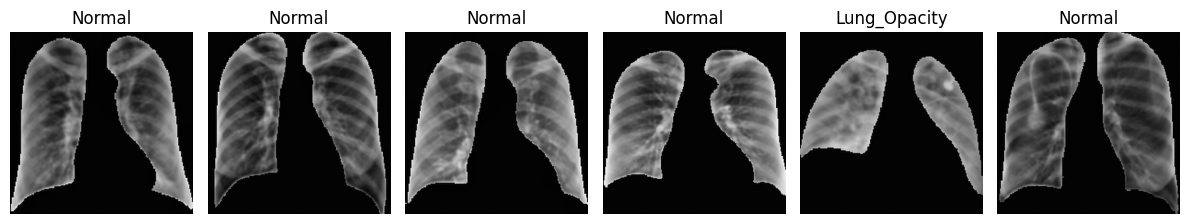

In [6]:
# Sanity check : un batch, la plage de valeurs après normalisation, quelques images
for imgs, lbls in train_ds.take(1):
    print("Batch shape:", imgs.shape, imgs.dtype)
    print("Min/max après normalisation:", float(tf.reduce_min(imgs)), float(tf.reduce_max(imgs)))

    plt.figure(figsize=(12, 4))
    for i in range(min(6, imgs.shape[0])):
        plt.subplot(1, 6, i + 1)
        plt.imshow(imgs[i, :, :, 0], cmap="gray")
        plt.title(CLASSES[int(lbls[i])])
        plt.axis("off")
    plt.tight_layout()
    plt.show()

## 3. Class weights (dataset déséquilibré)

In [7]:
train_labels = np.concatenate([y.numpy() for _, y in train_ds])
class_weights = compute_class_weight("balanced", classes=np.unique(train_labels), y=train_labels)
class_weight_dict = dict(enumerate(class_weights))
print("Class weights:", {CLASSES[k]: round(v, 3) for k, v in class_weight_dict.items()})

Class weights: {'COVID': np.float64(1.434), 'Normal': np.float64(0.519), 'Lung_Opacity': np.float64(0.883), 'Viral Pneumonia': np.float64(4.075)}


## 4. CNN custom

In [ ]:
def build_cnn(input_shape, num_classes):
    inputs = tf.keras.Input(shape=input_shape)

    # Data augmentation : actif seulement en training (model.fit), inerte en evaluate/predict
    x = layers.RandomFlip("horizontal")(inputs)
    x = layers.RandomRotation(0.05)(x)
    x = layers.RandomZoom(0.1)(x)

    for filters in [32, 64, 128, 256]:
        x = layers.Conv2D(filters, 3, padding="same", activation="relu")(x)
        x = layers.BatchNormalization()(x)
        x = layers.MaxPooling2D()(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    return Model(inputs, outputs, name="covid_cnn")


model = build_cnn((IMG_SIZE, IMG_SIZE, 1), len(CLASSES))
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
model.summary()

Model: "covid_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 256, 256, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip (RandomFlip)        │ (None, 256, 256, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 256, 256, 1)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 256, 256, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 256, 256, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256, 256, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 423,172 (1.61 MB)

 Trainable params: 422,212 (1.61 MB)

 Non-trainable params: 960 (3.75 KB)

: 

## 5. Entraînement

In [9]:
run_name = f"cnn_custom_{datetime.now().strftime('%Y%m%d-%H%M%S')}"

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6),
    tf.keras.callbacks.ModelCheckpoint(
        MODELS_DIR / f"{run_name}_best.keras", monitor="val_loss", save_best_only=True
    ),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weight_dict,
    callbacks=callbacks,
)

Epoch 1/30
463/463 ━━━━━━━━━━━━━━━━━━━━ 120s 202ms/step - accuracy: 0.5831 - loss: 0.8712 - val_accuracy: 0.4658 - val_loss: 2.5893 - learning_rate: 0.0010
Epoch 2/30


: 

: 

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history["loss"], label="train")
axes[0].plot(history.history["val_loss"], label="val")
axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(history.history["accuracy"], label="train")
axes[1].plot(history.history["val_accuracy"], label="val")
axes[1].set_title("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

## 6. Évaluation sur le jeu de test

In [ ]:
test_loss, test_acc = model.evaluate(test_ds, verbose=0)
print(f"Test loss: {test_loss:.4f}  Test accuracy: {test_acc:.4f}")

y_test = np.concatenate([y.numpy() for _, y in test_ds])  # test_ds n'est pas shuffle : ordre stable
y_pred_proba = model.predict(test_ds, verbose=0)
y_pred = np.argmax(y_pred_proba, axis=1)

print("\nClassification report:\n")
print(classification_report(y_test, y_pred, target_names=CLASSES))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASSES, yticklabels=CLASSES)
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.title("Matrice de confusion")
plt.tight_layout()
plt.show()

## 7. Sauvegarde du modèle final

In [ ]:
final_path = MODELS_DIR / f"{run_name}_final.keras"
model.save(final_path)
print(f"Modèle sauvegardé dans : {final_path}")